In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.fft import fft, fftfreq, fftshift
rcParams.update({'figure.autolayout': True})
import os
import IPython


In [92]:

def f(x):
    return np.exp(-50 * (x - 0.5)**2)

#solution to 1a
def F_analytic(k):
    return np.sqrt(np.pi/50.0) * np.exp(-k**2 / 200.0) * np.exp(-1j * k / 2)

def dft_forward(xn):
    N = len(xn)
    Xk = np.zeros(N, dtype=complex)
    for k in range(N):
        temp = 0.0 + 0.0j
        for n in range(N):
            temp += xn[n] * np.exp(-2j * np.pi * k * n / N)
        Xk[k] = temp
    return Xk


def dft_inverse(Xk):
    N = len(Xk)
    xn = np.zeros(N, dtype=complex)

    for n in range(N):
        temp = 0.0 + 0.0j
        for k in range(N):
            temp += Xk[k] * np.exp(2j * np.pi * k * n / N)
        xn[n] = temp / N
    return xn

In [93]:
N = 8
x = np.linspace(0, 1, N, endpoint=False)
xn = np.exp(-50 * (x - 0.5)**2)

Xk = dft_forward(xn)
xn_back = dft_inverse(Xk)

print(np.allclose(xn, xn_back))

True


In [94]:
#sum points
L = 1.0
N_values = [128, 64, 32]
x = np.linspace(0.0, L, N, endpoint=False)
dx = x[1] - x[0]
xn = f(x)

In [95]:
#define K space
def k_grid(N, L=1.0):
    m = np.arange(N)
    freq = np.where(m < N//2, m, m - N) / L #sort into K space
    return 2.0 * np.pi * freq

k = k_grid(N, L)
Xk = dft_forward(xn)
F_num = dx * Xk

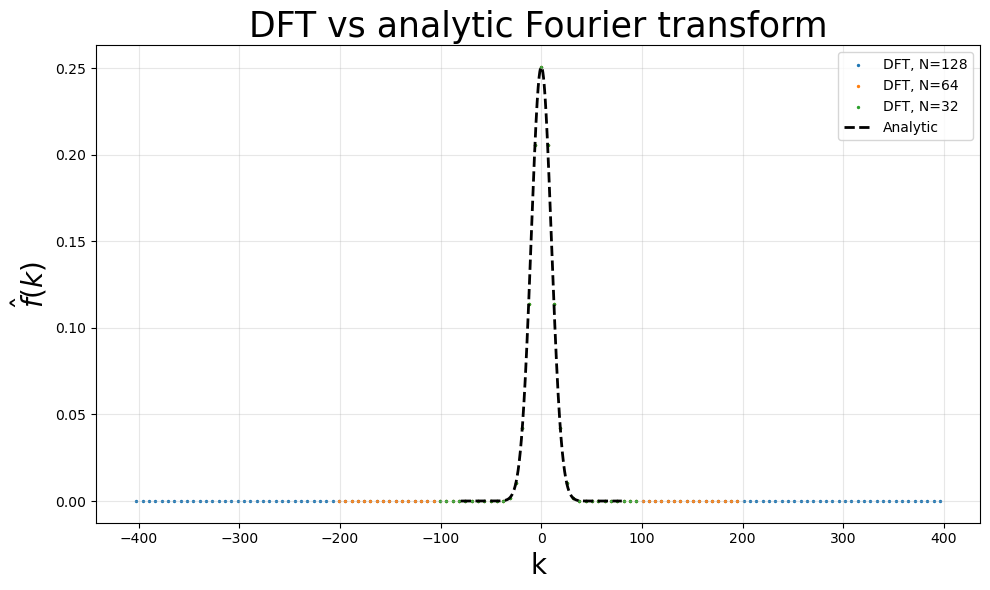

In [96]:
plt.figure(figsize=(10, 6))

for N in N_values:
    x = np.linspace(0.0, L, N, endpoint=False)
    dx = x[1] - x[0]
    xn = f(x)

    Xk = dft_forward(xn)
    k = k_grid(N, L)
    F_num = dx * Xk

    idx = np.argsort(k)
    plt.scatter(k[idx], np.abs(F_num[idx]), s = 2, label=f'DFT, N={N}')

# analytic curve on a dense k-grid
k_dense = np.linspace(-80, 80, 2000)
plt.plot(k_dense, np.abs(F_analytic(k_dense)), 'k--', linewidth=2, label='Analytic')

plt.xlabel('k',fontsize = 20)
plt.ylabel(r'$\hat{f}(k)$',fontsize = 20)
plt.title('DFT vs analytic Fourier transform', fontsize = 25)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

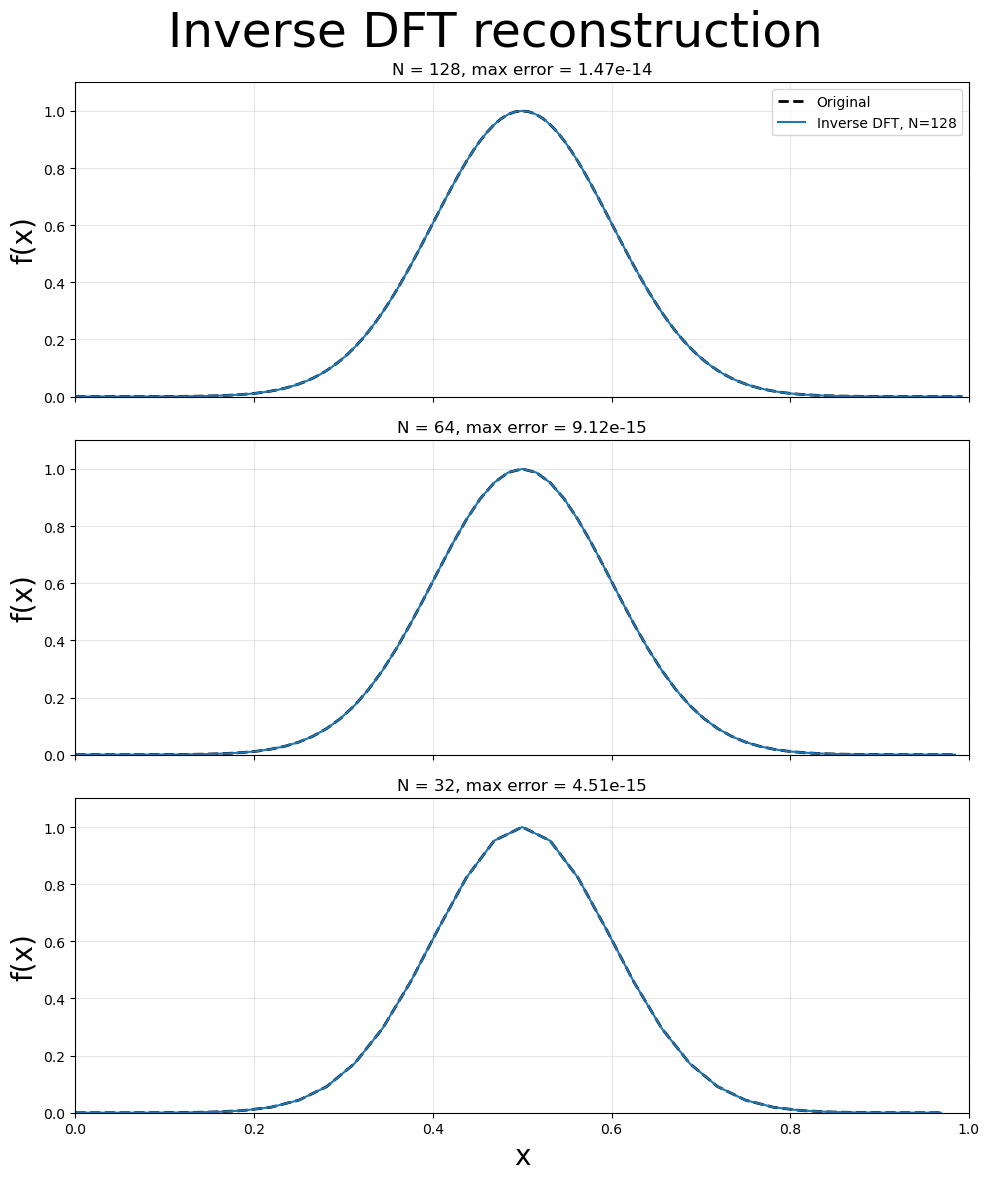

In [97]:
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True, sharey=True)

for ax, N in zip(axes, N_values):
    x = np.linspace(0.0, L, N, endpoint=False)
    xn = f(x)

    Xk = dft_forward(xn)
    xn_recovered = dft_inverse(Xk)

    ax.plot(x, xn, 'k--', linewidth=2, label='Original')
    ax.plot(x, xn_recovered.real, label=f'Inverse DFT, N={N}')

    err = np.max(np.abs(xn - xn_recovered))
    ax.set_ylabel('f(x)',fontsize = 20)
    ax.set_title(f'N = {N}, max error = {err:.2e}')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('x', fontsize = 20)

# keep same axis on all three
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.1)

axes[0].legend()

plt.suptitle('Inverse DFT reconstruction', y=0.98, fontsize = 35)
plt.tight_layout()
plt.show()

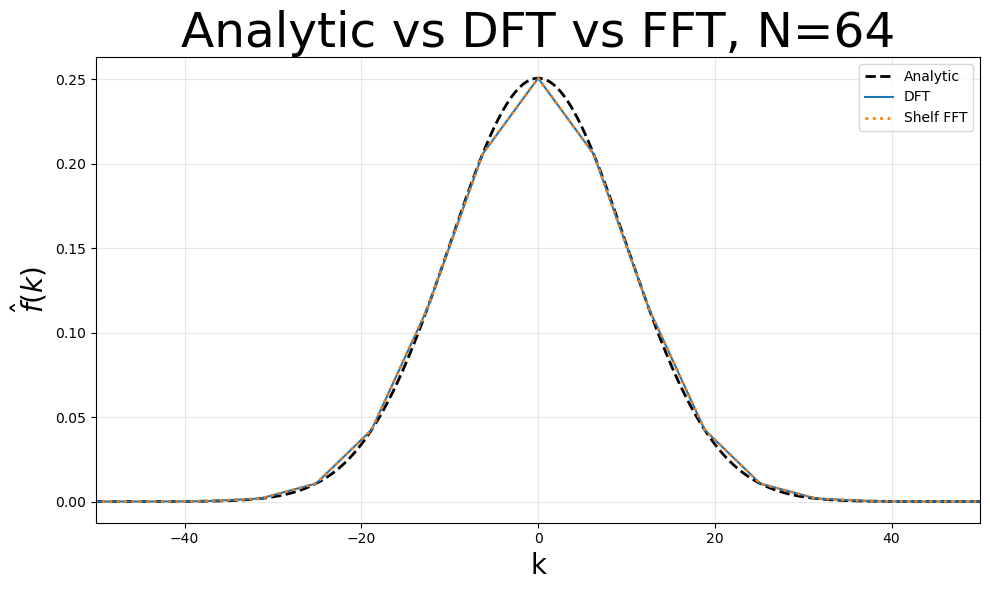

In [98]:
L = 1.0
N = 64

x = np.linspace(0.0, L, N, endpoint=False)
dx = x[1] - x[0]
xn = f(x)

X_dft = dft_forward(xn)
X_shelf = fft(xn)


F_dft = dx * X_dft
F_shelf = dx * X_shelf

k = 2.0 * np.pi * fftfreq(N, d=dx)

k_shift = fftshift(k)
F_dft_shift = fftshift(F_dft)
F_shelf_shift = fftshift(F_shelf)

k_dense = np.linspace(k_shift.min(), k_shift.max(), 2000)
F_an_dense = F_analytic(k_dense)

plt.figure(figsize=(10, 6))
plt.plot(k_dense, np.abs(F_an_dense), 'k--', linewidth=2, label='Analytic')
plt.plot(k_shift, np.abs(F_dft_shift), label='DFT')
plt.plot(k_shift, np.abs(F_shelf_shift), ':', linewidth=2, label='Shelf FFT')

plt.xlabel('k',fontsize = 20)
plt.ylabel(r'$\hat{f}(k)$',fontsize = 20)
plt.xlim(-50,50)
plt.title(f'Analytic vs DFT vs FFT, N={N}', fontsize = 35)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [99]:
import time
def time_dft(N, runs=100):
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    xn = f(x)
    dft_forward(xn)

    t0 = time.perf_counter()
    for _ in range(runs):
        dft_forward(xn)
    t1 = time.perf_counter()

    return (t1 - t0) / runs


def time_fft(N, runs=100):
    x = np.linspace(0.0, 1.0, N, endpoint=False)
    xn = f(x)
    fft(xn)

    t0 = time.perf_counter()
    for _ in range(runs):
        fft(xn)
    t1 = time.perf_counter()

    return (t1 - t0) / runs

In [ ]:
N_dft = [2**j for j in range(3, 12)]   # 2^3 to 2^11
N_fft = [2**j for j in range(3, 21)]   # 2^3 to 2^20

times_dft = []
times_fft = []

for N in N_dft:
    td = time_dft(N, runs=100)
    times_dft.append(td)

for N in N_fft:
    tf = time_fft(N, runs=100)
    times_fft.append(tf)

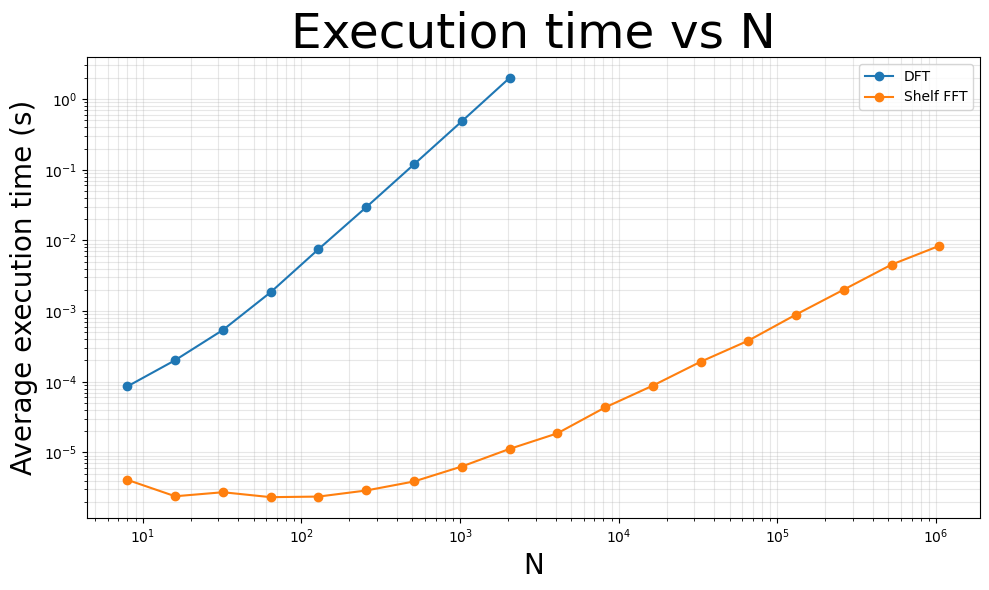

In [ ]:
plt.figure(figsize=(10, 6))
plt.loglog(N_dft, times_dft, 'o-', label='DFT')
plt.loglog(N_fft, times_fft, 'o-', label='Shelf FFT')

plt.xlabel('N', fontsize = 20)
plt.ylabel('Average execution time (s)', fontsize = 20)
plt.title('Execution time vs N',fontsize = 35)
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()

In [ ]:
# Runge-Kutta 4 from HW3 with a tweak for complex plane
def RK4_system(ti, yi, df, dt, steps):
    yi = np.array(yi, dtype=complex)

    t_array = np.zeros(steps + 1, dtype=float)
    y_array = np.zeros((steps + 1, len(yi)), dtype=complex)

    t_array[0] = ti
    y_array[0] = yi

    for i in range(steps):
        k1 = df(yi, ti)
        k2 = df(yi + 0.5 * dt * k1, ti + 0.5 * dt)
        k3 = df(yi + 0.5 * dt * k2, ti + 0.5 * dt)
        k4 = df(yi + dt * k3, ti + dt)

        yi = yi + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        ti = ti + dt

        t_array[i + 1] = ti
        y_array[i + 1] = yi

    return t_array, y_array


In [ ]:
L = 1.0
N = 128
alpha = 0.005
dt = 0.001
T = 5.0
steps = int(T / dt)

x = np.linspace(0.0, L, N, endpoint=False)
dx = x[1] - x[0]

u0 = np.exp(-50.0 * (x - 0.5)**2)
m = np.arange(N)
k = 2.0 * np.pi * np.where(m < N//2, m, m - N) / L

#transformed heat equation
def dUdt(U, t):
    return -alpha * (k**2) * U

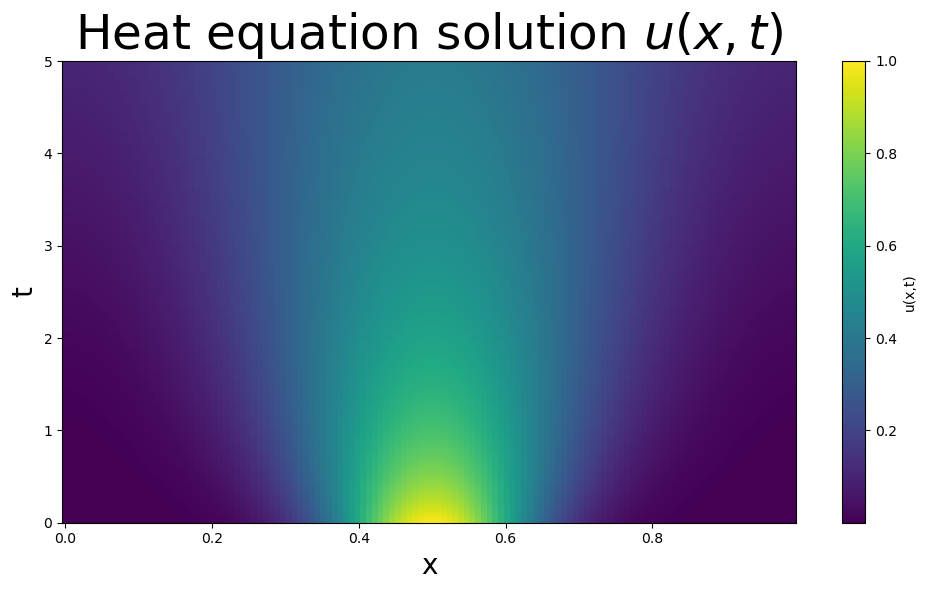

In [ ]:
U0 = dft_forward(u0)
t_array, U_hist = RK4_system(0.0, U0, dUdt, dt, steps)
u_hist = np.zeros((steps + 1, N), dtype=complex)

for i in range(steps + 1):
    u_hist[i] = dft_inverse(U_hist[i])

u_hist_real = u_hist.real

plt.figure(figsize=(10, 6))
plt.pcolormesh(x, t_array, u_hist_real, shading='auto')
plt.xlabel('x', fontsize = 20)
plt.ylabel('t',fontsize = 20)
plt.title(r'Heat equation solution $u(x,t)$',fontsize = 35)
plt.colorbar(label='u(x,t)')
plt.show()

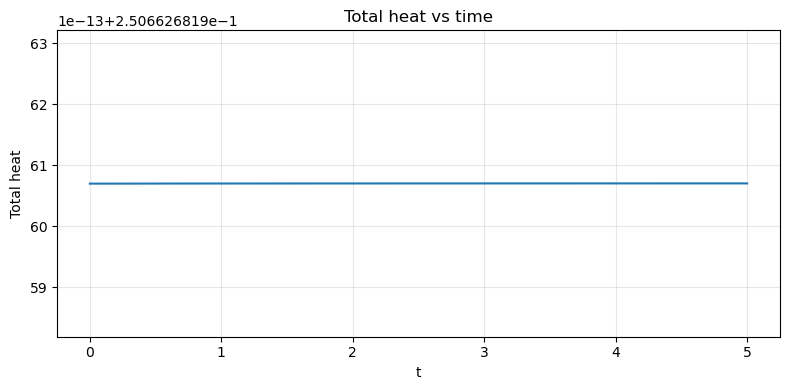

Initial heat: 0.2506626818660697
Final heat:   0.25066268186607016
Max change:   4.996003610813204e-16


In [ ]:
heat = dx * np.sum(u_hist_real, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t_array, heat)
plt.xlabel('t')
plt.ylabel('Total heat')
plt.title('Total heat vs time')
plt.grid(True, alpha=0.3)
plt.show()

print("Initial heat:", heat[0])
print("Final heat:  ", heat[-1])
print("Max change:  ", np.max(np.abs(heat - heat[0])))

In [ ]:
alpha = 0.02
dt = 0.001
T = 5.0
steps = int(T / dt)
    
def dUdt(U, t):
    return -alpha * (k**2) * U

t_array2, U_hist2 = RK4_system(0.0, U0, dUdt, dt, steps)

u_hist2 = np.zeros((steps + 1, N), dtype=complex)
for i in range(steps + 1):
    u_hist2[i] = dft_inverse(U_hist2[i])

u_hist2_real = u_hist2.real

plt.figure(figsize=(8, 5))
plt.pcolormesh(x, t_array2, u_hist2_real, shading='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title(r'Heat equation with larger $\alpha$ and $\Delta t$')
plt.colorbar(label='u(x,t)')
plt.show()

/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/670704406.py:7: RuntimeWarning: overflow encountered in multiply
  return -alpha * (k**2) * U
/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/373440783.py:15: RuntimeWarning: invalid value encountered in multiply
  k4 = df(yi + dt * k3, ti + dt)
/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/670704406.py:7: RuntimeWarning: invalid value encountered in multiply
  return -alpha * (k**2) * U
/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/373440783.py:17: RuntimeWarning: invalid value encountered in multiply
  yi = yi + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/373440783.py:14: RuntimeWarning: invalid value encountered in multiply
  k3 = df(yi + 0.5 * dt * k2, ti + 0.5 * dt)
/var/folders/sm/sjz00q7943zdql3vzxcjy5rw0000gn/T/ipykernel_4049/373440783.py:17: RuntimeWarning: overflow encountered in multiply
  yi = yi + (dt /

KeyboardInterrupt: 

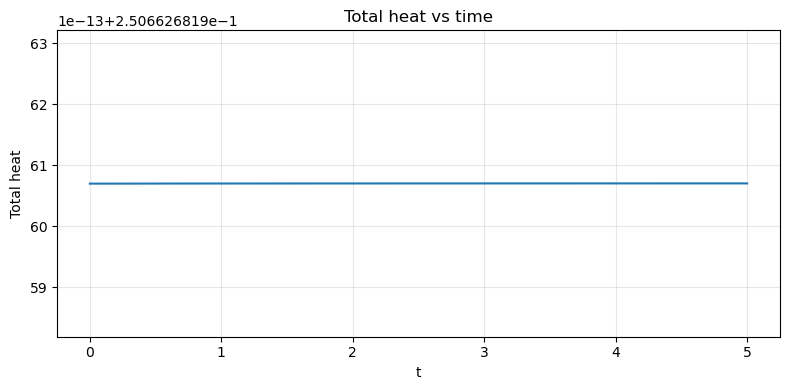

Initial heat: 0.2506626818660697
Final heat:   0.25066268186607016
Max change:   4.996003610813204e-16


In [ ]:
heat = dx * np.sum(u_hist_real, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(t_array, heat)
plt.xlabel('t')
plt.ylabel('Total heat')
plt.title('Total heat vs time')
plt.grid(True, alpha=0.3)
plt.show()

print("Initial heat:", heat[0])
print("Final heat:  ", heat[-1])
print("Max change:  ", np.max(np.abs(heat - heat[0])))